In [9]:
import os

print(os.listdir(r"C:\Users\masee\OneDrive\Desktop\Medical_Image_Classification"))

['dataset', 'models', 'notebooks', 'README.md', 'reports', 'screenshots']


In [10]:
import os

print(os.listdir(r"C:\Users\masee\OneDrive\Desktop\Medical_Image_Classification\dataset"))

['test', 'train']


In [11]:
import os

train_path = r"C:\Users\masee\OneDrive\Desktop\Medical_Image_Classification\dataset\train"
test_path = r"C:\Users\masee\OneDrive\Desktop\Medical_Image_Classification\dataset\test"

print(os.path.exists(train_path))
print(os.path.exists(test_path))

True
True


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = r"C:\Users\masee\OneDrive\Desktop\Medical_Image_Classification\dataset\train"
test_path = r"C:\Users\masee\OneDrive\Desktop\Medical_Image_Classification\dataset\test"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


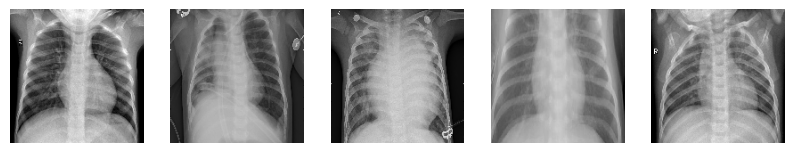

In [13]:
images, labels = next(train_data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(150,150,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

C:\Users\masee\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [17]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8844 - loss: 0.3477 - val_accuracy: 0.6955 - val_loss: 1.2756
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9705 - loss: 0.0877 - val_accuracy: 0.7981 - val_loss: 0.6762
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9747 - loss: 0.0689 - val_accuracy: 0.7532 - val_loss: 0.9809
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 162s 991ms/step - accuracy: 0.9839 - loss: 0.0452 - val_accuracy: 0.7019 - val_loss: 1.6594
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.9856 - loss: 0.0409 - val_accuracy: 0.7500 - val_loss: 1.5226


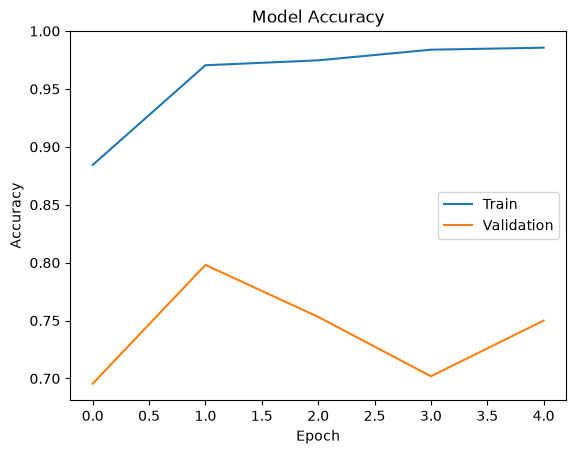

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

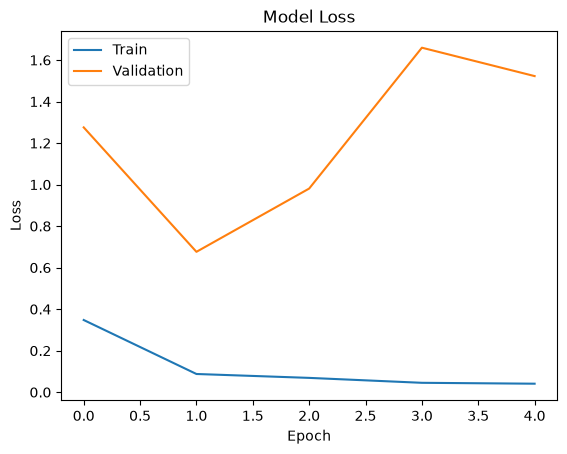

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [20]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 644ms/step - accuracy: 0.7500 - loss: 1.5226
Test Accuracy: 0.75
Test Loss: 1.5226101875305176


In [21]:
model.save("medical_image_model.h5")

In [22]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 586ms/step - accuracy: 0.7500 - loss: 1.5226
Test Accuracy: 0.75
